In [36]:
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             average_precision_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")

In [37]:
# Version A = training data BEFORE SMOTE (real companies only)
train_A = pd.read_csv("../../data/train_pca.csv")

# Version B = training data AFTER SMOTE (includes fake bankrupt rows)
train_B = pd.read_csv("../../results/outputs/final_preprocessed_train.csv")

# Test data (SMOTE is never applied to this)
test = pd.read_csv("../../results/outputs/final_preprocessed_test.csv")

# Split each table into X (features) and y (the answer)
X_A = train_A.drop(columns="Bankrupt?")
y_A = train_A["Bankrupt?"]

X_B = train_B.drop(columns="Bankrupt?")
y_B = train_B["Bankrupt?"]

X_test = test.drop(columns="Bankrupt?")
y_test = test["Bankrupt?"]

print("Version A:", X_A.shape, y_A.value_counts().to_dict())
print("Version B:", X_B.shape, y_B.value_counts().to_dict())
print("Test     :", X_test.shape, y_test.value_counts().to_dict())

Version A: (5455, 29) {0: 5279, 1: 176}
Version B: (10558, 29) {0: 5279, 1: 5279}
Test     : (1364, 29) {0: 1320, 1: 44}


here accuracy is unreliable and and it demonstrated via dummyclassifier

In [39]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_A, y_A)
dummy_predictions = dummy.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, dummy_predictions), 3), "  accuracy is high but")
print("Recall  :", recall_score(y_test, dummy_predictions), "  it catches ZERO bankruptcies")
print("F1      :", f1_score(y_test, dummy_predictions))

Accuracy: 0.968   accuracy is high but
Recall  : 0.0   it catches ZERO bankruptcies
F1      : 0.0


before training or cross valadating the helper functions r defined here

In [41]:
# 5 folds, each keeping the same % of bankrupt companies. random_state keeps the folds the same every run.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def cv_scores(model, X, y):
    """Cross-validate a model and return the average precision, recall and F1."""
    results = cross_validate(model, X, y, cv=cv, scoring=["precision", "recall", "f1"], n_jobs=-1)
    return {
        "precision": round(float(results["test_precision"].mean()), 3),
        "recall":    round(float(results["test_recall"].mean()), 3),
        "f1":        round(float(results["test_f1"].mean()), 3),
    }


def evaluate(model, X_test, y_test):
    """Score a TRAINED model on the test set. Returns (scores, confusion matrix)."""
    predictions   = model.predict(X_test)               # 0 or 1 for each company
    probabilities = model.predict_proba(X_test)[:, 1]   # chance of being bankrupt

    scores = {
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall":    recall_score(y_test, predictions),
        "f1":        f1_score(y_test, predictions),
        "pr_auc":    average_precision_score(y_test, probabilities),
        "roc_auc":   roc_auc_score(y_test, probabilities),
        "accuracy":  accuracy_score(y_test, predictions),   # only to show it is misleading
    }
    matrix = confusion_matrix(y_test, predictions)
    return scores, matrix

next up r the experiments

1st we r gonna see what difference SMOTE makes on the evaluvation metrics

here we use A version of the training data set

In [43]:
# no SMOTE
model_no_smote = LogisticRegression(max_iter=2000)
scores_no_smote = cv_scores(model_no_smote, X_A, y_A)

# SMOTE inside the folds
model_with_smote = make_pipeline(SMOTE(random_state=42), LogisticRegression(max_iter=2000))
scores_smote = cv_scores(model_with_smote, X_A, y_A)

print("A, no SMOTE               :", scores_no_smote)
print("A, SMOTE inside the folds:", scores_smote)

A, no SMOTE               : {'precision': 0.497, 'recall': 0.176, 'f1': 0.258}
A, SMOTE inside the folds: {'precision': 0.17, 'recall': 0.835, 'f1': 0.282}


In the next experiment we r gonna compare the B version of the training data set which we had applied SMOTE to the whole data set

this creates data leakage when doing Cross validations since this creates a synthetic fake twin by slightly adjesting the already exsisting feature values 
but when we apply cross validation(im planning to apply 5 fold cross validation) it creates devides our traing data intoto 5 folds and make one as temporary test set  and other 4 as study materials we do this till each one of 5 folds becomes test set and other 4 becomes study materials then get the mean scores throughout the 5 folds
if we hv Applied SMOTE before dividing into the folds a sythetic twin can end of in the study material while the other one end up in the test set giving the model a chance to cheat

to avoid that we need to apply SMOTE fold by fold

in the next step im gonna prove how the data leakage affects the scores

In [44]:
# WRONG way: cross-validate on the file that was already SMOTEd
model_wrong = LogisticRegression(max_iter=2000)
scores_wrong = cv_scores(model_wrong, X_B, y_B)

# RIGHT way: the SMOTE-inside-folds result from Experiment 1
scores_right = scores_smote

print("WRONG (CV on file B)              :", scores_wrong)
print("RIGHT (CV on A, SMOTE inside folds):", scores_right)

WRONG (CV on file B)              : {'precision': 0.868, 'recall': 0.904, 'f1': 0.885}
RIGHT (CV on A, SMOTE inside folds): {'precision': 0.17, 'recall': 0.835, 'f1': 0.282}


As we can see the data leakage has made the metrics skyrocket(in WRONG one)


In this one we r gonna use GridSearchCV 

In [46]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
class_weights = [None, "balanced"]
scoring = {"f1": "f1", "pr_auc": "average_precision"}   # scores to record for each combination

# --- Search 1: no SMOTE ---
grid_plain = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid={"C": C_values, "class_weight": class_weights},
    cv=cv, scoring=scoring, refit="f1", n_jobs=-1)
grid_plain.fit(X_A, y_A)

# --- Search 2: SMOTE inside the folds ---
# (inside a pipeline, settings are written as <step name>__<setting>)
grid_smote = GridSearchCV(
    make_pipeline(SMOTE(random_state=42), LogisticRegression(max_iter=2000)),
    param_grid={"logisticregression__C": C_values, "logisticregression__class_weight": class_weights},
    cv=cv, scoring=scoring, refit="f1", n_jobs=-1)
grid_smote.fit(X_A, y_A)

print("Search 1 (no SMOTE)   best CV F1:", round(grid_plain.best_score_, 3), "->", grid_plain.best_params_)
print("Search 2 (with SMOTE) best CV F1:", round(grid_smote.best_score_, 3), "->", grid_smote.best_params_)

Search 1 (no SMOTE)   best CV F1: 0.286 -> {'C': 0.01, 'class_weight': 'balanced'}
Search 2 (with SMOTE) best CV F1: 0.285 -> {'logisticregression__C': 0.001, 'logisticregression__class_weight': None}


Here we used The hyperparameter as C value and class weight while those r model hyper parameters we can maybe also consider application of SMOTE and NO SMOTE to be a pipe line hyperparameter


In [47]:
def make_table(grid, used_smote):
    """Turn one finished GridSearchCV into a small table, one row per combination."""
    results = pd.DataFrame(grid.cv_results_)
    table = pd.DataFrame({
        "SMOTE":        [used_smote] * len(results),
        "settings":     results["params"].astype(str).str.replace("logisticregression__", ""),
        "CV F1":        results["mean_test_f1"],
        "CV F1 std":    results["std_test_f1"],
        "CV PR-AUC":    results["mean_test_pr_auc"],
    })
    return table


table_plain = make_table(grid_plain, "no")
table_smote = make_table(grid_smote, "yes")

all_varieties = pd.concat([table_plain, table_smote])
all_varieties = all_varieties.sort_values("CV F1", ascending=False)
all_varieties = all_varieties.reset_index(drop=True).round(3)

print(len(all_varieties), "varieties trained")
all_varieties.head(24)

24 varieties trained


,SMOTE,settings,CV F1,CV F1 std,CV PR-AUC
0,no,"{'C': 0.01, 'class_weight': 'balanced'}",0.286,0.020,0.374
1,yes,"{'C': 0.001, 'class_weight': None}",0.285,0.017,0.358
2,yes,"{'C': 0.001, 'class_weight': 'balanced'}",0.285,0.017,0.358
3,no,"{'C': 0.1, 'class_weight': 'balanced'}",0.284,0.028,0.370
4,yes,"{'C': 100, 'class_weight': None}",0.284,0.025,0.355
5,yes,"{'C': 100, 'class_weight': 'balanced'}",0.284,0.025,0.355
6,yes,"{'C': 10, 'class_weight': 'balanced'}",0.283,0.024,0.356
7,yes,"{'C': 10, 'class_weight': None}",0.283,0.024,0.356
8,yes,"{'C': 0.01, 'class_weight': 'balanced'}",0.283,0.019,0.375
9,yes,"{'C': 0.01, 'class_weight': None}",0.283,0.019,0.375


In [48]:
print("Best CV F1, no SMOTE  :", round(grid_plain.best_score_, 3))
print("Best CV F1, with SMOTE:", round(grid_smote.best_score_, 3))

# Step 1 + 2: which search won?
if grid_plain.best_score_ >= grid_smote.best_score_:
    best_grid = grid_plain
    smote_won = "no"
else:
    best_grid = grid_smote
    smote_won = "yes"

# Step 3: take the winning settings and the ready-trained model out of the winning search
best_settings = best_grid.best_params_
best_model = best_grid.best_estimator_

print()
print("SMOTE used in the winner?:", smote_won)
print("Winning settings         :", best_settings)
print("Best model               :", best_model)

Best CV F1, no SMOTE  : 0.286
Best CV F1, with SMOTE: 0.285

SMOTE used in the winner?: no
Winning settings         : {'C': 0.01, 'class_weight': 'balanced'}
Best model               : LogisticRegression(C=0.01, class_weight='balanced', max_iter=2000)


In [49]:
# evaluate() asks best_model to predict the test companies and scores the answers
scores, cm = evaluate(best_model, X_test, y_test)

print("Test scores:")
print("  precision:", round(scores["precision"], 3))
print("  recall   :", round(scores["recall"], 3))
print("  f1       :", round(scores["f1"], 3))
print("  pr_auc   :", round(scores["pr_auc"], 3))
print("  roc_auc  :", round(scores["roc_auc"], 3))
print("  accuracy :", round(scores["accuracy"], 3), "(not used to judge the model)")

Test scores:
  precision: 0.174
  recall   : 0.818
  f1       : 0.287
  pr_auc   : 0.379
  roc_auc  : 0.93
  accuracy : 0.869 (not used to judge the model)


In [50]:
# The confusion matrix in words
tn, fp, fn, tp = cm.ravel()

print("Healthy companies correctly cleared (TN):", tn)
print("False alarms, healthy flagged bankrupt (FP):", fp)
print("Bankruptcies missed (FN):", fn)
print("Bankruptcies caught (TP):", tp)

Healthy companies correctly cleared (TN): 1149
False alarms, healthy flagged bankrupt (FP): 171
Bankruptcies missed (FN): 8
Bankruptcies caught (TP): 36


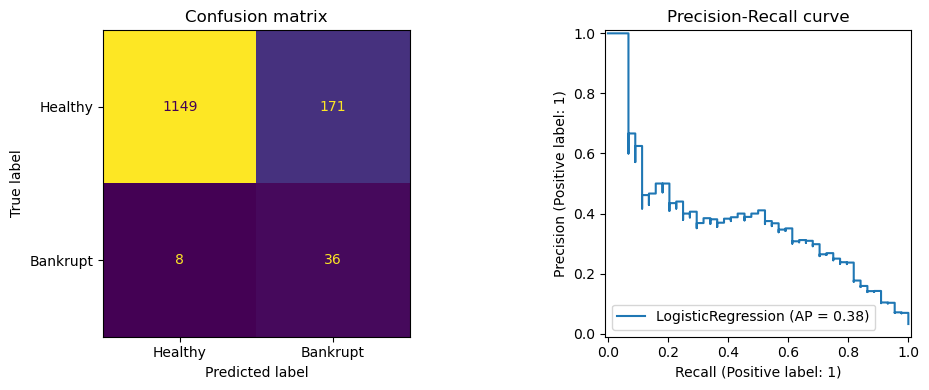

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Bankrupt"]).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Confusion matrix")

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1])
ax[1].set_title("Precision-Recall curve")

plt.tight_layout()
plt.show()

In [54]:
MEMBER = "IT25102594 - Bandara O A A Y S"
MODEL = "Logistic Regression"

new_row = pd.DataFrame([{
    "member": MEMBER,
    "model": MODEL,
    "best_settings": str(best_settings),
    "used_smote_in_cv": smote_won,
    "n_varieties": len(all_varieties),
    "cv_f1": round(best_grid.best_score_, 4),
    "precision": round(scores["precision"], 4),
    "recall": round(scores["recall"], 4),
    "f1": round(scores["f1"], 4),
    "pr_auc": round(scores["pr_auc"], 4),
    "roc_auc": round(scores["roc_auc"], 4),
    "accuracy": round(scores["accuracy"], 4),
    "TN": tn, "FP": fp, "FN": fn, "TP": tp,
}])

display_row = new_row.T
display_row.columns = ["Results"] # Gives a clean header to the values
display_row

,Results
member,IT25102594 - Bandara O A A Y S
model,Logistic Regression
best_settings,"{'C': 0.01, 'class_weight': 'balanced'}"
used_smote_in_cv,no
n_varieties,24
cv_f1,0.2856
precision,0.1739
recall,0.8182
f1,0.2869
pr_auc,0.3788
